In [1]:
import seaborn as sns
import  matplotlib.pyplot as plt 
import pandas as pd

On charge les données + on ajoute une variable qui comptabilise la proportion de temps par jour, pour chaque chaîne et thématique

In [2]:
from load_data.donnees_chargement import load_sujet_tele

sujet_tele = load_sujet_tele()
#on calcule le temps total du JT de chaque jour pour chaque chaîne:
sujet_tele['Temps_total_JT'] = sujet_tele.groupby(['Date','Chaîne'])['Duree_sec'].transform(sum)
#on créer une colonne "prop" qui contient la proportion de temps dans l'émission dédiée à un type de sujet 
sujet_tele['Prop']=sujet_tele['Duree_sec']/sujet_tele['Temps_total_JT']
sujet_tele.head(20)

/home/onyxia/work/Projet_python_2A/load_data/donnees_chargement.py:18: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  sujet_tele['Temps_total_JT'] = sujet_tele.groupby(['Date','Chaîne'])['Duree_sec'].transform(sum)
/tmp/ipykernel_13572/672375099.py:5: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  sujet_tele['Temps_total_JT'] = sujet_tele.groupby(['Date','Chaîne'])['Duree_sec'].transform(sum)


,Date,Chaîne,Thématique,Nb_sujets,Duree_sec,Temps_total_JT,Prop
0,2000-01-02,France 3,Catastrophes,2,235,1254,0.187400
1,2000-01-02,France 3,Culture-loisirs,1,138,1254,0.110048
2,2000-01-02,France 3,Environnement,3,306,1254,0.244019
3,2000-01-02,France 3,International,2,241,1254,0.192185
4,2000-01-02,France 3,Société,2,160,1254,0.127592
5,2000-01-02,France 3,Sport,2,174,1254,0.138756
6,2000-01-03,France 3,Catastrophes,3,329,1190,0.276471
7,2000-01-03,France 3,Culture-loisirs,1,38,1190,0.031933
8,2000-01-03,France 3,Economie,2,191,1190,0.160504
9,2000-01-03,France 3,Education,2,224,1190,0.188235


In [3]:
#ensemble des chaînes de sujet_tele
sujet_tele['Chaîne'].unique()

array(['France 3', 'Arte', 'M6', 'France 2', 'TF1'], dtype=object)

On 

In [4]:
#on filtre les données pour chaque chaîne : 
sujet_tele_M6 = sujet_tele[sujet_tele['Chaîne']=='M6']
sujet_tele_FR3 = sujet_tele[sujet_tele['Chaîne']=='France 3']
sujet_tele_Arte = sujet_tele[sujet_tele['Chaîne']=='Arte']
sujet_tele_FR2 = sujet_tele[sujet_tele['Chaîne']=='France 2']
sujet_tele_TF1 = sujet_tele[sujet_tele['Chaîne']=='TF1']

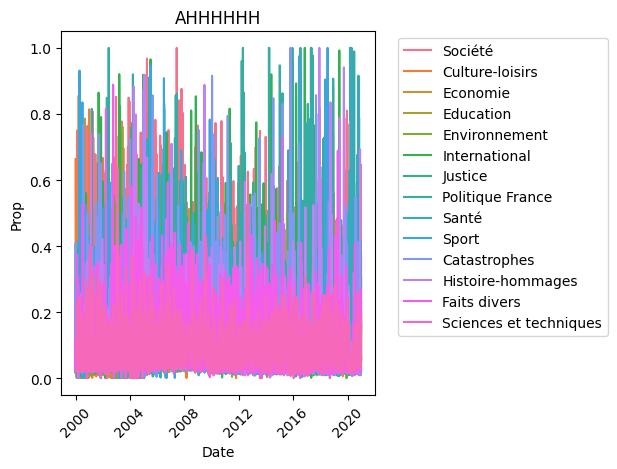

In [5]:
#on représente avec seaborn : M6
sns.lineplot(data=sujet_tele_M6, x='Date', y='Prop', hue='Thématique')
plt.title('AHHHHHH')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# peu lisible : on va lisser prendre la proportion moyenne par mois 

In [6]:
# on va regrouper les proportions par mois pour plus de lisibilité

sujet_tele_M6_month = sujet_tele_M6.groupby([sujet_tele_M6['Date'].dt.to_period('M'), 'Thématique'])['Prop'].mean().reset_index()
sujet_tele_M6_month['Date'] = sujet_tele_M6_month['Date'].dt.to_timestamp()
sujet_tele_M6_month


,Date,Thématique,Prop
0,2000-01-01,Catastrophes,0.171436
1,2000-01-01,Culture-loisirs,0.166632
2,2000-01-01,Economie,0.136145
3,2000-01-01,Education,0.197997
4,2000-01-01,Environnement,0.140472
...,...,...,...
3498,2020-12-01,Politique France,0.087086
3499,2020-12-01,Santé,0.244334
3500,2020-12-01,Sciences et techniques,0.092624
3501,2020-12-01,Société,0.238170


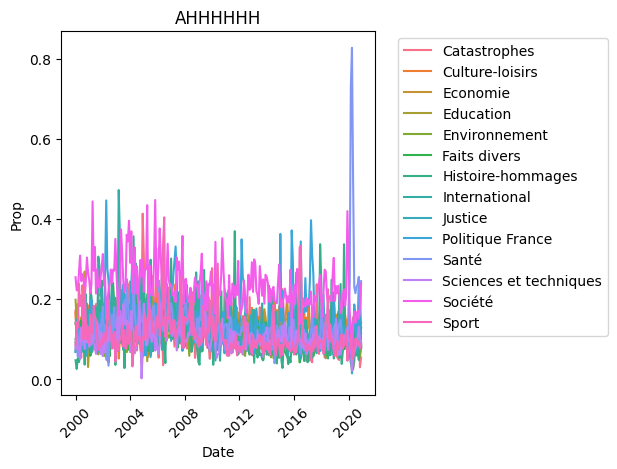

In [7]:
sns.lineplot(data=sujet_tele_M6_month, x='Date', y='Prop', hue='Thématique')
plt.title('AHHHHHH')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

au lieu d'avoir un plot par chaîne on pourrait avoir un plot par thématique où on compare les chaînes.

Ci-dessous on fait une fonction pour adapter la table sujet_tele à l'échelle de temps : par année ou par mois.
Exemple: par mois = renvoyer une table avec pour chaque chaîne, chaque thématique et selon le mois, le temps cumulé par thématique et le temps total cumulé par chaîne dans le mois.

In [8]:
def sujet_convert(indic, table, Date = 'Date', Thématique = 'Thématique', Duree_sec = 'Duree_sec', Chaine = 'Chaîne'):
    if indic not in ("Y", "M"):
        raise ValueError("Y pour year ou M pour Month à mettre en entrée")
    table_convert= table.groupby([table[Date].dt.to_period(indic), Chaine, Thématique])[Duree_sec].sum().reset_index()
    table_convert.rename(columns={Duree_sec: 'Temps cumul'}, inplace=True)
    table_convert_mean = table.groupby([table[Date].dt.to_period(indic), Chaine, Thématique])[Duree_sec].mean().reset_index()
    table_convert_mean.rename(columns={Duree_sec: 'Temps moyen'}, inplace=True)
    table_convert['Temps moyen'] = table_convert_mean['Temps moyen']
    return table_convert

In [9]:
sujet_tele_Y = sujet_convert("M", table = sujet_tele)
sujet_tele_Y

,Date,Chaîne,Thématique,Temps cumul,Temps moyen
0,2000-01,Arte,Catastrophes,1222,135.777778
1,2000-01,Arte,Culture-loisirs,4654,193.916667
2,2000-01,Arte,Economie,2357,168.357143
3,2000-01,Arte,Education,46,23.000000
4,2000-01,Arte,Environnement,2186,198.727273
...,...,...,...,...,...
17283,2020-12,TF1,Politique France,2567,183.357143
17284,2020-12,TF1,Santé,23892,770.709677
17285,2020-12,TF1,Sciences et techniques,3016,274.181818
17286,2020-12,TF1,Société,11214,386.689655


*** Idée : ajuster un modèle de type ARIMA/SARIMA à une thématique d'une chaîne pour faire ensuite une prédiction

In [10]:
#liste des thématiques 
sujet_tele['Thématique'].unique()

array(['Catastrophes', 'Culture-loisirs', 'Environnement',
       'International', 'Société', 'Sport', 'Economie', 'Education',
       'Politique France', 'Santé', 'Histoire-hommages', 'Justice',
       'Faits divers', 'Sciences et techniques'], dtype=object)

In [ ]:
### M6 - culture 
sujet_tele_M6.loc[:,'Date'] = pd.to_datetime(sujet_tele_M6.loc[:,'Date'], dayfirst= True) #on transforme en datetime la colonne date
sujet_tele_M6[sujet_tele_M6["Thématique"]== 'Culture-loisirs']
culture_M6 = sujet_tele_M6[sujet_tele_M6["Thématique"]== 'Culture-loisirs']
culture_M6 = sujet_convert(indic = "M", table = culture_M6)

KeyError: 'Duree_sec'

In [12]:
plt.plot(culture_M6['Date'], culture_M6['Duree_sec'])
plt.xlabel('Date')
plt.ylabel('Valeur')
plt.title('Évolution temporelle')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KeyError: 'Duree_sec'

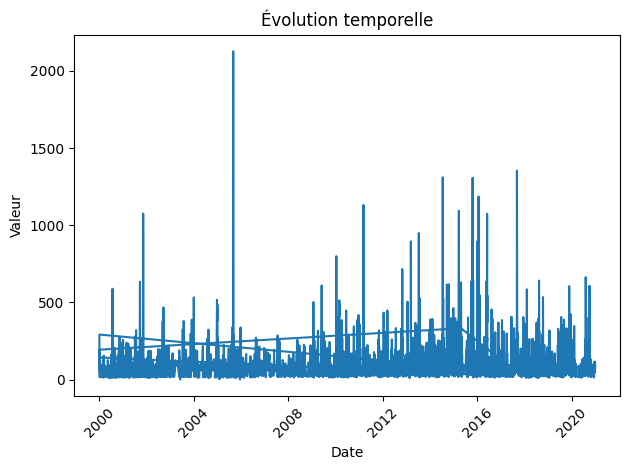

In [13]:
# M6 catastrophe
cata_M6 = sujet_tele_M6[sujet_tele_M6["Thématique"]== 'Catastrophes']

plt.plot(cata_M6['Date'], cata_M6['Duree_sec'])
plt.xlabel('Date')
plt.ylabel('Valeur')
plt.title('Évolution temporelle')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<b>FR3<b>

In [ ]:
sujet_tele_FR3.loc[:,'Date'] = pd.to_datetime(sujet_tele_FR3.loc[:,'Date'], dayfirst= True) #on transforme en datetime la colonne date
culture_FR3 = sujet_tele_FR3[sujet_tele_FR3["Thématique"]== 'Culture-loisirs']

plt.plot(culture_FR3['Date'], culture_FR3['Duree_sec'])
plt.xlabel('Date')
plt.ylabel('Valeur')
plt.title('Évolution temporelle')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KeyError: "None of [Index([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,\n       ...\n       12, 12, 12, 12, 12, 12, 12, 12, 12,  1],\n      dtype='int32', length=4779)] are in the [columns]"

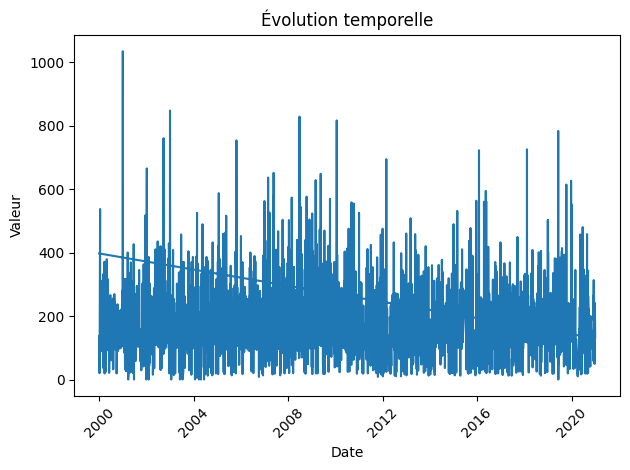

In [15]:
sport_FR3 = sujet_tele_FR3[sujet_tele_FR3["Thématique"]== 'Sport']
plt.plot(culture_FR3['Date'], culture_FR3['Duree_sec'])
plt.xlabel('Date')
plt.ylabel('Valeur')
plt.title('Évolution temporelle')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<b>ARTE<b>

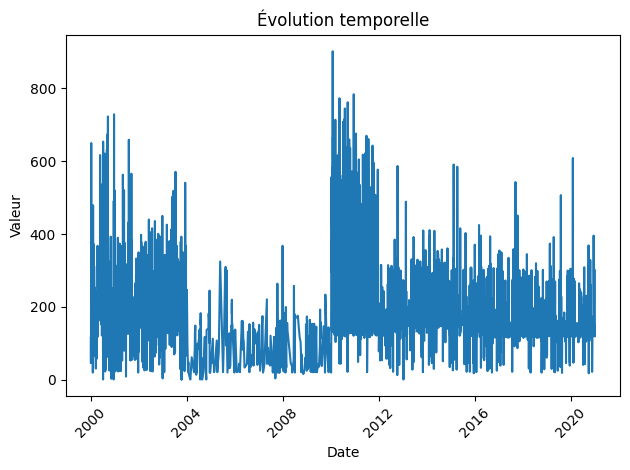

In [16]:
culture_arte = sujet_tele_Arte[sujet_tele_Arte["Thématique"]== 'Culture-loisirs']
culture_arte
plt.plot(culture_arte['Date'], culture_arte['Duree_sec'])
plt.xlabel('Date')
plt.ylabel('Valeur')
plt.title('Évolution temporelle')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

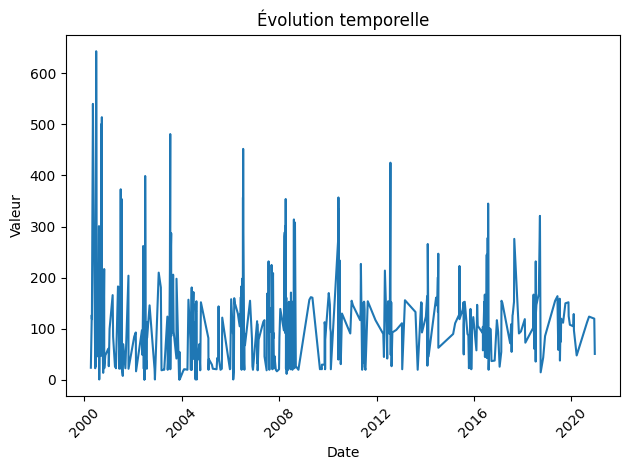

In [17]:
sport_arte = sujet_tele_Arte[sujet_tele_Arte["Thématique"]== 'Sport']
plt.plot(sport_arte['Date'], sport_arte['Duree_sec'])
plt.xlabel('Date')
plt.ylabel('Valeur')
plt.title('Évolution temporelle')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<b>TF1<b>

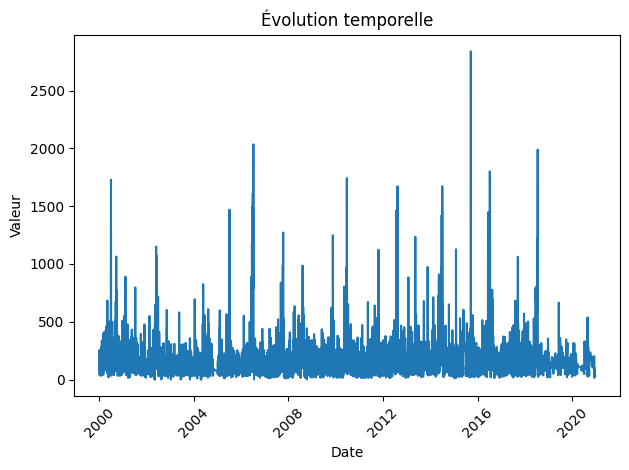

In [18]:
sport_TF1 = sujet_tele_TF1[sujet_tele_TF1['Thématique'] == 'Sport']
plt.plot(sport_TF1['Date'], sport_TF1['Duree_sec'])
plt.xlabel('Date')
plt.ylabel('Valeur')
plt.title('Évolution temporelle')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<b>On va plutôt faire une regression logistique du temps de parole avec pour covariable la thématique du JT et la chaîne de diffusion<b>

1) faire une table avec les données : temps de parole femme et thématique qui contient : 
- la proportion de temps de parole F par rapport aux H
- La chaîne du JT en question 
- la thématique majoritairement abordée

In [19]:
from load_data.donnees_chargement import load_parite
parite = load_parite()
parite

/home/onyxia/work/Projet_python_2A/load_data/donnees_chargement.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  parite['week_day_number'] = parite['week_day'].replace({


,media_type,channel_code,channel_name,is_public_channel,date,week_day,school_holiday_zones,civil_holyday,hour,male_duration,female_duration,music_duration,week_day_number
636822,tv,ART,ARTE,True,2010-01-01,Friday,ABC,True,12,829.06,371.28,2056.80,5
636823,tv,ART,ARTE,True,2010-01-01,Friday,ABC,True,14,148.42,68.56,2993.40,5
636824,tv,ART,ARTE,True,2010-01-01,Friday,ABC,True,18,1722.84,307.90,1238.96,5
636825,tv,ART,ARTE,True,2010-01-01,Friday,ABC,True,21,2714.88,329.62,286.16,5
636826,tv,ART,ARTE,True,2010-01-02,Saturday,ABC,False,11,1254.78,1243.14,1070.86,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1013627,tv,TF1,TF1,False,2019-02-28,Thursday,AC,False,19,1261.04,1343.74,826.58,4
1013628,tv,TF1,TF1,False,2019-02-28,Thursday,AC,False,20,1738.18,1304.92,477.12,4
1013629,tv,TF1,TF1,False,2019-02-28,Thursday,AC,False,21,1841.44,818.52,850.54,4
1013630,tv,TF1,TF1,False,2019-02-28,Thursday,AC,False,22,1817.82,747.30,972.06,4


In [20]:
parite['channel_name'].unique() # on a gardé que les chaînes de JT

array(['ARTE', 'France 2', 'France 3', 'M6', 'TF1'], dtype=object)

In [21]:
sujet_tele['Chaîne'].unique()

array(['France 3', 'Arte', 'M6', 'France 2', 'TF1'], dtype=object)

In [23]:
parite.columns

Index(['media_type', 'channel_code', 'channel_name', 'is_public_channel',
       'date', 'week_day', 'school_holiday_zones', 'civil_holyday', 'hour',
       'male_duration', 'female_duration', 'music_duration',
       'week_day_number'],
      dtype='object')

In [ ]:
#on retire les colonnes que nous n'utiliserons pas
parite.drop(columns=['media_type',
'channel_code', 
'week_day', 
'school_holiday_zones', 
'civil_holyday'],inplace=True)

In [30]:
#on change les noms des colonnes que les tables doivent partager (Chaîne et Date)
parite.rename(columns={'channel_name' : 'Chaîne',
'date' : 'Date'}, inplace = True)
parite

,Chaîne,is_public_channel,Date,hour,male_duration,female_duration,music_duration,week_day_number
636822,ARTE,True,2010-01-01,12,829.06,371.28,2056.80,5
636823,ARTE,True,2010-01-01,14,148.42,68.56,2993.40,5
636824,ARTE,True,2010-01-01,18,1722.84,307.90,1238.96,5
636825,ARTE,True,2010-01-01,21,2714.88,329.62,286.16,5
636826,ARTE,True,2010-01-02,11,1254.78,1243.14,1070.86,6
...,...,...,...,...,...,...,...,...
1013627,TF1,False,2019-02-28,19,1261.04,1343.74,826.58,4
1013628,TF1,False,2019-02-28,20,1738.18,1304.92,477.12,4
1013629,TF1,False,2019-02-28,21,1841.44,818.52,850.54,4
1013630,TF1,False,2019-02-28,22,1817.82,747.30,972.06,4


In [ ]:
#on fait une jointure avec la table sujet_tele sur les colonnes'Chaîne' et 'Date'
